In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
def cross_matrix(vec):
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

def uncross_matrix(mat):
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def omega_dot(t, omega, I_B):
    skew_omega= cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)
    

In [2]:
omega1 = np.array([.9,.1,0])
omega2 = np.array([0.1,0.9,0])

I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)


time = np.linspace(0,10,1000)
sol1 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   # pass function, not its output
                [0,10], omega1,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
sol2 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   # pass function, not its output
                [0,10], omega2,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
omegadot_sol1 = sol1.y
omegadot_sol2 = sol2.y


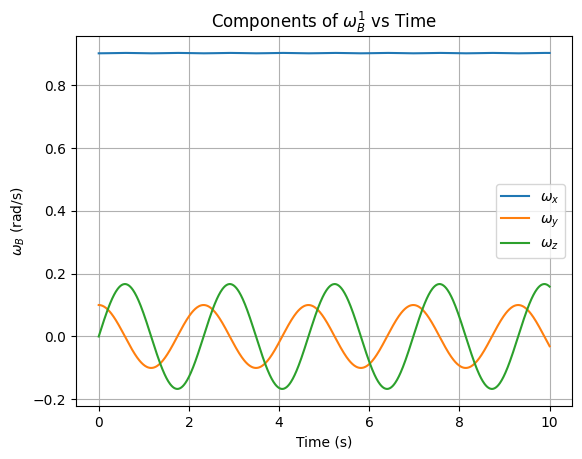

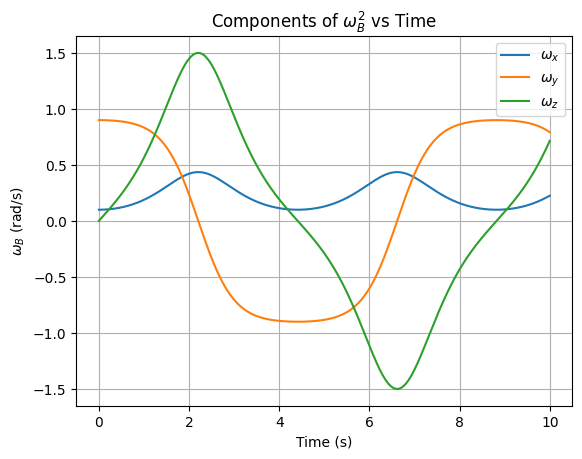

In [3]:
# --- Plot 1: omega1 components vs time ---
plt.figure(1)
plt.clf()
plt.plot(sol1.t, omegadot_sol1[0,:], label=r'$\omega_x$')
plt.plot(sol1.t, omegadot_sol1[1,:], label=r'$\omega_y$')
plt.plot(sol1.t, omegadot_sol1[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B^{1}$ vs Time')
plt.legend()
plt.grid(True)
plt.show()
# --- Plot 2: omega2 components vs time ---
plt.figure(2)
plt.clf()
plt.plot(sol2.t, omegadot_sol2[0,:], label=r'$\omega_x$')
plt.plot(sol2.t, omegadot_sol2[1,:], label=r'$\omega_y$')
plt.plot(sol2.t, omegadot_sol2[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B^{2}$ vs Time')
plt.legend()
plt.grid(True)
plt.show()


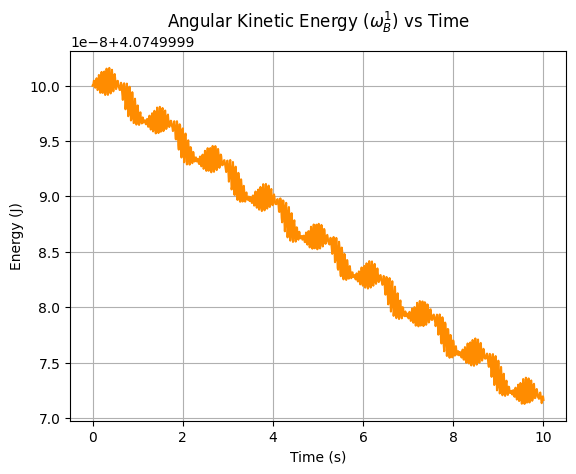

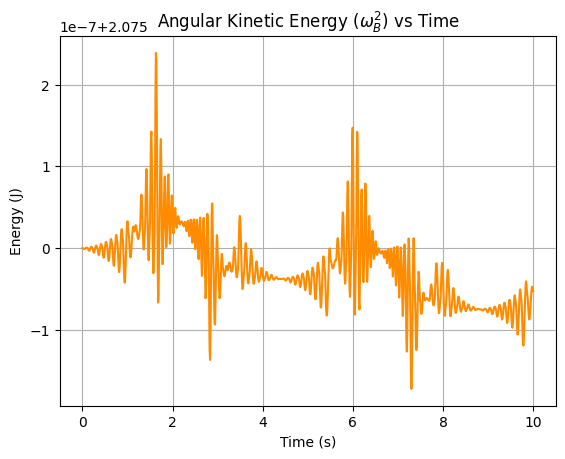

In [4]:
# --- Plot 2: Angular kinetic energy vs time ---
# T = 0.5 * omega^T @ I_B @ omega
T1 = 0.5 * np.einsum('ij,jk,ki->i', omegadot_sol1.T, I_B, omegadot_sol1)

plt.figure(1)
plt.clf()
plt.plot(sol2.t, T1, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy ($\omega_B^{1}$) vs Time')
plt.grid(True)
plt.show()

T2 = 0.5 * np.einsum('ij,jk,ki->i', omegadot_sol2.T, I_B, omegadot_sol2)

plt.figure(1)
plt.clf()
plt.plot(sol2.t, T2, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy ($\omega_B^{2})$ vs Time')
plt.grid(True)
plt.show()

In [5]:
# Problem 3 Euler-Lagrange Simulation
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
m1 = symbols("m1",  positive=True)   # mass of each body-link end mass
m2 = symbols("m2",  positive=True)   # mass at tip of extendable leg
w  = symbols("w",   positive=True)   # half-width of body link
g  = symbols("g",   positive=True)   # gravitational acceleration
omega = symbols("omega", positive=True)  # forcing frequency

# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta= Function('theta1', real=True)(t)
phi= Function('theta2',real=True)(t)
theta_dot= Function('phi_dot',real=True)(t)
phi_dot= Function('theta2_dot', real=True)(t)
l     = Function('l',     real=True)(t)

# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

In [6]:
# T_world_to_body: translate to (x,y), rotate by theta
T1 = T(R_z(theta), Matrix([[0],[0],[0]])) @ T(Matrix.eye(3,3), Matrix([[x],[y],[0]])) #Trasnfrom to center joint
T1 = simplify(T1)

# T Matrix to Right and Left Masses
T1_right = T1 @ T(Matrix.eye(3,3), Matrix([[w],[0],[0]]))
T1_right = simplify(T1_right)
T1_left  = T1 @ T(Matrix.eye(3,3), Matrix([[-w],[0],[0]]))
T1_left = simplify(T1_left)

# T_body_to_leg: no translation (leg attaches at same joint), rotate by phi
T2 = T1 @ T(R_z(phi), Matrix([[0],[0],[0]])) @ T(Matrix.eye(3,3), Matrix([[0],[-l],[0]]))
T2 = simplify(T2)

In [7]:
bodytwist_r = simplify(T1_right.inv() @ diff(T1_right, t))  # for right m1
bodytwist_l = simplify(T1_left.inv() @ diff(T1_left, t))  # for left m1
bodytwist_2 = simplify(T2.inv() @ diff(T2, t))  # for m2

b_r = twist2vec(bodytwist_r)
b_l = twist2vec(bodytwist_l)
b_2 = twist2vec(bodytwist_2)

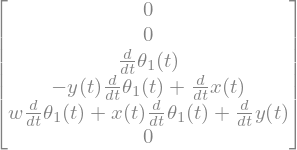

In [8]:
b_r

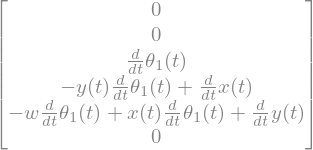

In [9]:
b_l

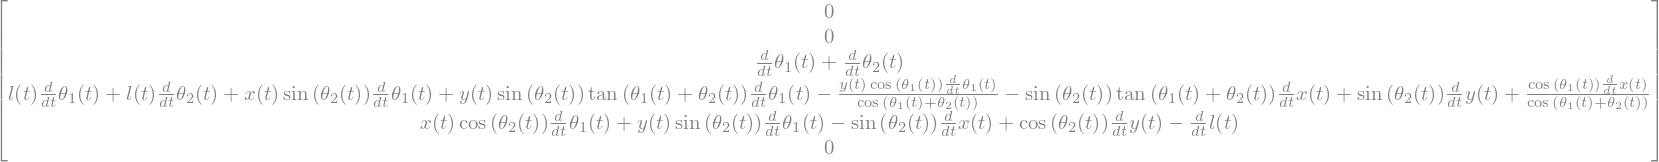

In [10]:
b_2

In [11]:
Gb1=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m1,0,0],
           [0,0,0,0,m1,0],
           [0,0,0,0,0,m1]])
     
Gb2=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m2,0,0],
           [0,0,0,0,m2,0],
           [0,0,0,0,0,m2]])
# Kinetic Energy
KEl=.5*b_l.T @ Gb1 @ b_l


In [12]:
KEr=.5*b_r.T @ Gb1 @ b_r

In [13]:
KE2=.5*b_2.T @ Gb2 @ b_2

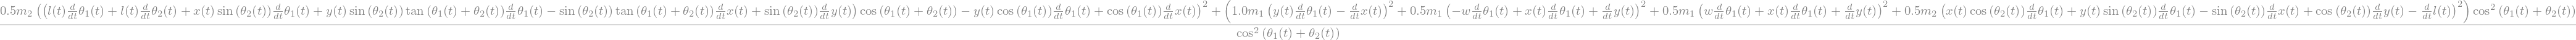

In [19]:
KE_tot= simplify(KEl[0] + KEr[0] + KE2[0])
KE_tot

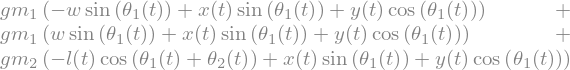

In [20]:
# Potential Energy
V = m1*g*T1_right[1,3] + m1*g*T1_left[1,3] + m2*g*T2[1,3]
V

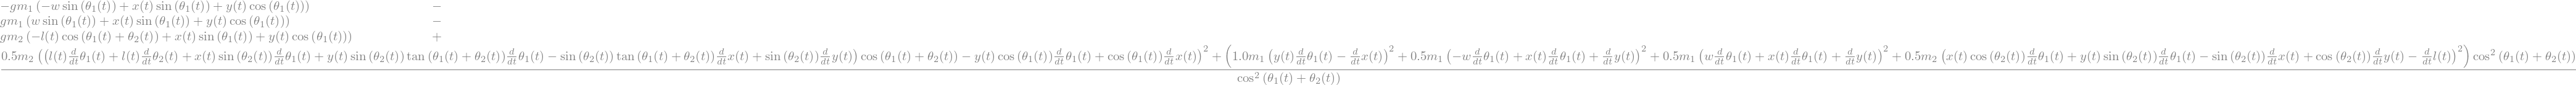

In [21]:
L=KE_tot - V
L

In [22]:
EOM_x     = nsimplify(diff(diff(L, diff(x, t)),     t) - diff(L, x))
EOM_y     = nsimplify(diff(diff(L, diff(y, t)),     t) - diff(L, y))
EOM_theta = nsimplify(diff(diff(L, diff(theta, t)), t) - diff(L, theta))
EOM_phi   = nsimplify(diff(diff(L, diff(phi, t)),   t) - diff(L, phi))
EOM_l     = nsimplify(diff(diff(L, diff(l, t)),     t) - diff(L, l))

In [ ]:
q      = [x, y, theta, phi, l]
q_dt   = [diff(qi, t)    for qi in q]
q_dtdt = [diff(qi, t, t) for qi in q]

#H = Matrix([[EOM_x], [EOM_y], [EOM_theta], [EOM_phi], [EOM_l]])
H = Matrix([[EOM_theta], [EOM_phi]])
mass= simplify(H.jacobian(q_dtdt))
mass[1,2]

In [ ]:
mass

In [ ]:
EOM_vec = simplify(H - mass * Matrix(q_dtdt))

In [ ]:
params_sym = [w, m1, m2, g]
 
M_lambda   = lambdify([q, q_dt, params_sym], mass,    modules='numpy')
EOM_lambda = lambdify([q, q_dt, params_sym], EOM_vec, modules='numpy')
 
KE_lambda = lambdify([q,q_dt,params],EOM)
PE_lambda = lambdify([q,q_dt,params],EOM)

In [37]:
params_= [1,1,1,9.8]
q_=[1,1]
q_dt_=[1,1]

In [38]:
def dyanamics(t,state, params):
    state= [theta1,theta2]
    q=[theta1,theta2]
    q_dt=[theta1_dot,theta2_dot]
    dydt=np.linalg.solve(M_lambda(q,q_dt,params), -EOM_lambda(q,q_dt,parans))
    return [theta1_dot,theta2_dot, dydt[0][0], dydt[1][0]

SyntaxError: incomplete input (3211332631.py, line 6)

In [ ]:
# ── Numerical parameters ──
w_    = 1.0    # half body width
m1_   = 1.0    # body end masses
m2_   = 1.0    # leg tip mass
g_    = 9.8
omega_val = 1.0  # forcing frequency (rad/s)
 
params_num = [w_, m1_, m2_, g_, omega_val]   # last entry is omega
 
# ── Initial conditions  [x, y, theta, phi, l, xd, yd, thd, phd, ld] ──
init_state = [0.0,   # x
              1.0,   # y  (start 1 m above ground)
              0.0,   # theta
              0.1,   # phi  (small initial leg angle)
              1.0,   # l    (leg length)
              0.0,   # x_dot
              0.0,   # y_dot
              0.0,   # theta_dot
              0.0,   # phi_dot
              0.0]   # l_dot
 
# ── Time span: 5 cycles of oscillation at omega_val ──
T_period = 2 * np.pi / omega_val
t_end    = 5 * T_period
dt       = 0.01
time     = np.linspace(0, t_end, int(t_end / dt))
 
print("\nRunning numerical integration...")
sol = solve_ivp(lambda t_val, y: dynamics(t_val, y, params_num),
                [0, t_end],
                init_state,
                t_eval=time,
                rtol=1e-8, atol=1e-8,
                method='RK45')
 
# ── Extract phi (index 3 in state) ──
phi_sol = sol.y[3, :]
 
# ── Plot phi over 5 cycles ──
plt.figure(figsize=(10, 4))
plt.plot(sol.t, phi_sol, linewidth=1.8, color='steelblue')
plt.xlabel('Time (s)', fontsize=13)
plt.ylabel(r'$\phi$ (rad)', fontsize=13)
plt.title(r'Leg angle $\phi$ over 5 oscillation cycles'
          r'  ($\tau_\phi = \sin(\omega t)$, $\tau_l = \cos(\omega t)$)', fontsize=13)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/phi_oscillation.png', dpi=150)
plt.show()
print("Done. Plot saved.")